In [20]:
import pandas as pd
import numpy as np
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import umap
import hdbscan
import re

In [3]:
train = pd.read_table('train.tsv')
train['item_description'] = train['item_description'].fillna("No description yet")
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")
train["category_name"] = train["category_name"].fillna("No category/No category/No category")
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)
print(train['cat_1'].value_counts().head(10))  

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Name: count, dtype: int64


In [29]:
#네임 + 디스크립션 합치기
train_Women = train[train['cat_1']=='Women']

train_Women_Handbag = train[(train['cat_1']=='Women') & (train['cat_2']=="Women's Handbags")]

train_Women_Handbag["name_description"] = (
    train_Women_Handbag["name"].fillna("") + " " +
    train_Women_Handbag["item_description"].fillna("")
)


/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/2931039290.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_Women_Handbag["name_description"] = (


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/2784330482.py:6: SyntaxWarning: invalid escape sequence '\s'
  r"\bbrand\s+new": "brandnew",
/Users/jeon-woojin/Desktop/python/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/2784330482.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_Women_Handbag["cluster"] = clusters


Top4 clusters:
cluster
36    1004
18     898
35     852
17     829
Name: count, dtype: int64


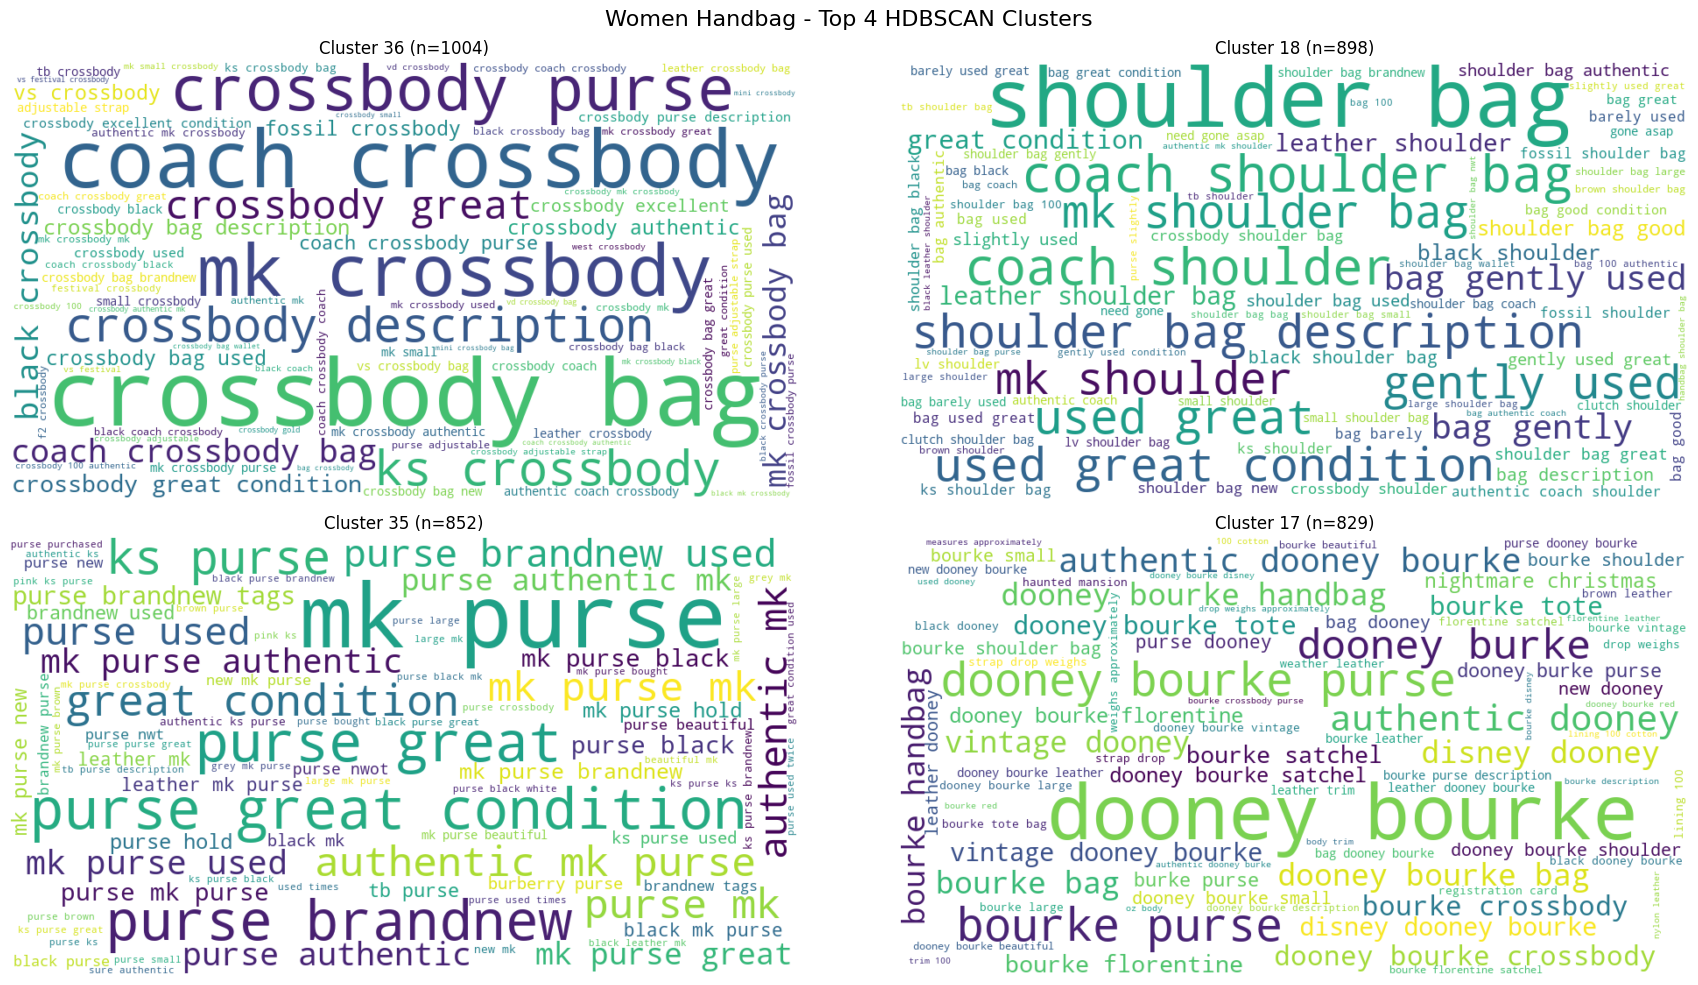

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

'''
brand_map1 = {
    r"\bbrand\s+new": "brandnew",
    r"\bfree\s+ship(ping)?\b" :"freeship",
    r"\bgray\b": "grey",
    r"\bbnwt\b": "nwt",
    r"\bquestions\b":"question",
    r"\bcomfy\b":"comfortable",
    r"\bvictoria(?:'|’)?s?\s+secret\b": "vs",  
    r"\bcalvin\s+klein\b": "ck",
    r"\bmichael\s+kors\b": "mk",
    r"\bamerican\s+eagle\b": "ae",
    r"\bkate\s+spade\b":"ks",
    r"\bkendra\s+scott\b": "kc",
    r"\blouis\s+vuitton\b": "lv",
    r"\bbrandy\s+melville\b":"bm",
    r"\bvera\s+bradley\b":"vd",
    r"\btory\s+burch\b":"tb",
    r"\bnorth\s+face\b":"nf",
    r"\bforever\s+21\b":"f2",
    r"\bcomme\s+des\s+garcons?\b": "cdg",
    r"\bjessica\s+simpson\b":"js",
    }  

def normalize_brands(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    for pattern, replacement in brand_map1.items():
        text = re.sub(pattern, replacement, text)
    return text

train_Women_Handbag['name_description'] = train_Women_Handbag['name_description'].apply(normalize_brands)


no_use_word = ['rm', 'description','size',
    'condition','great','good','excellent','worn','used','new','like','firm','price','shipping','freeship','bundle',
    'tags','tag','brandnew','free','authentic','just', 'times','save','bought','items','box',
    'brand','material','light','long','twice','wear','washed','nwot','nwt','stains','flaws',
    'gently','wore','home','10','don','check','comes','little','100',
    'retail','inside','big','ask','question','dust'
    ]
'''
custom_stopwords = list(ENGLISH_STOP_WORDS.union(no_use_word))

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(2,3),
    min_df=5,
    stop_words='english'         #custom_stopwords
)

X = vectorizer.fit_transform(train_Women_Handbag["name_description"].fillna(""))
feature_names = vectorizer.get_feature_names_out()


import umap

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=10,
    metric="cosine",
    random_state=42
)

X_umap = umap_model.fit_transform(X)

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="leaf"
)

clusters = clusterer.fit_predict(X_umap)
train_Women_Handbag["cluster"] = clusters

vc = train_Women_Handbag.loc[
    train_Women_Handbag["cluster"] != -1, "cluster"
].value_counts()

top4 = vc.head(4).index.tolist()

print("Top4 clusters:")
print(vc.head(4))

import matplotlib.pyplot as plt
from wordcloud import WordCloud

global_mean = np.asarray(X.mean(axis=0)).ravel()

def build_freqs(cid, top_n=80):
    idx = np.where(clusters == cid)[0]
    X_c = X[idx]

    c_mean = np.asarray(X_c.mean(axis=0)).ravel()

    score = c_mean - global_mean

    top_idx = score.argsort()[-top_n:][::-1]
    freqs = {feature_names[j]: float(score[j])
             for j in top_idx if score[j] > 0}
    if len(freqs) < 10:
        top_idx = c_mean.argsort()[-top_n:][::-1]
        freqs = {feature_names[j]: float(c_mean[j])
                 for j in top_idx if c_mean[j] > 0}

    return freqs
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()

for ax, cid in zip(axes, top4):
    freqs = build_freqs(cid)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Cluster {cid} (n={vc[cid]})")

plt.suptitle("Women Handbag - Top 4 HDBSCAN Clusters", fontsize=16)
plt.tight_layout()
plt.show()

In [50]:
train_Women_Athletic = train[(train['cat_1']=='Women') & (train['cat_2']=="Athletic Apparel")]

#네임 + 디스크립션 합치기
train_Women = train[train['cat_1']=='Women']

train_Women_Athletic = train[(train['cat_1']=='Women') & (train['cat_2']=="Athletic Apparel")]


train_Women_Athletic["name_description"] = (
    train_Women_Athletic["name"].fillna("") + " " +
    train_Women_Athletic["item_description"].fillna("")
)


/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/872918513.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_Women_Athletic["name_description"] = (


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/4210527894.py:6: SyntaxWarning: invalid escape sequence '\s'
  r"\bbrand\s+new": "brandnew",
/Users/jeon-woojin/Desktop/python/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/3m/2p4scd0107qfx4clslwxs3r80000gn/T/ipykernel_40817/4210527894.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_Women_Athletic["cluster"] = clusters


Top4 clusters:
cluster
9      2762
34     1915
101    1222
91     1198
Name: count, dtype: int64


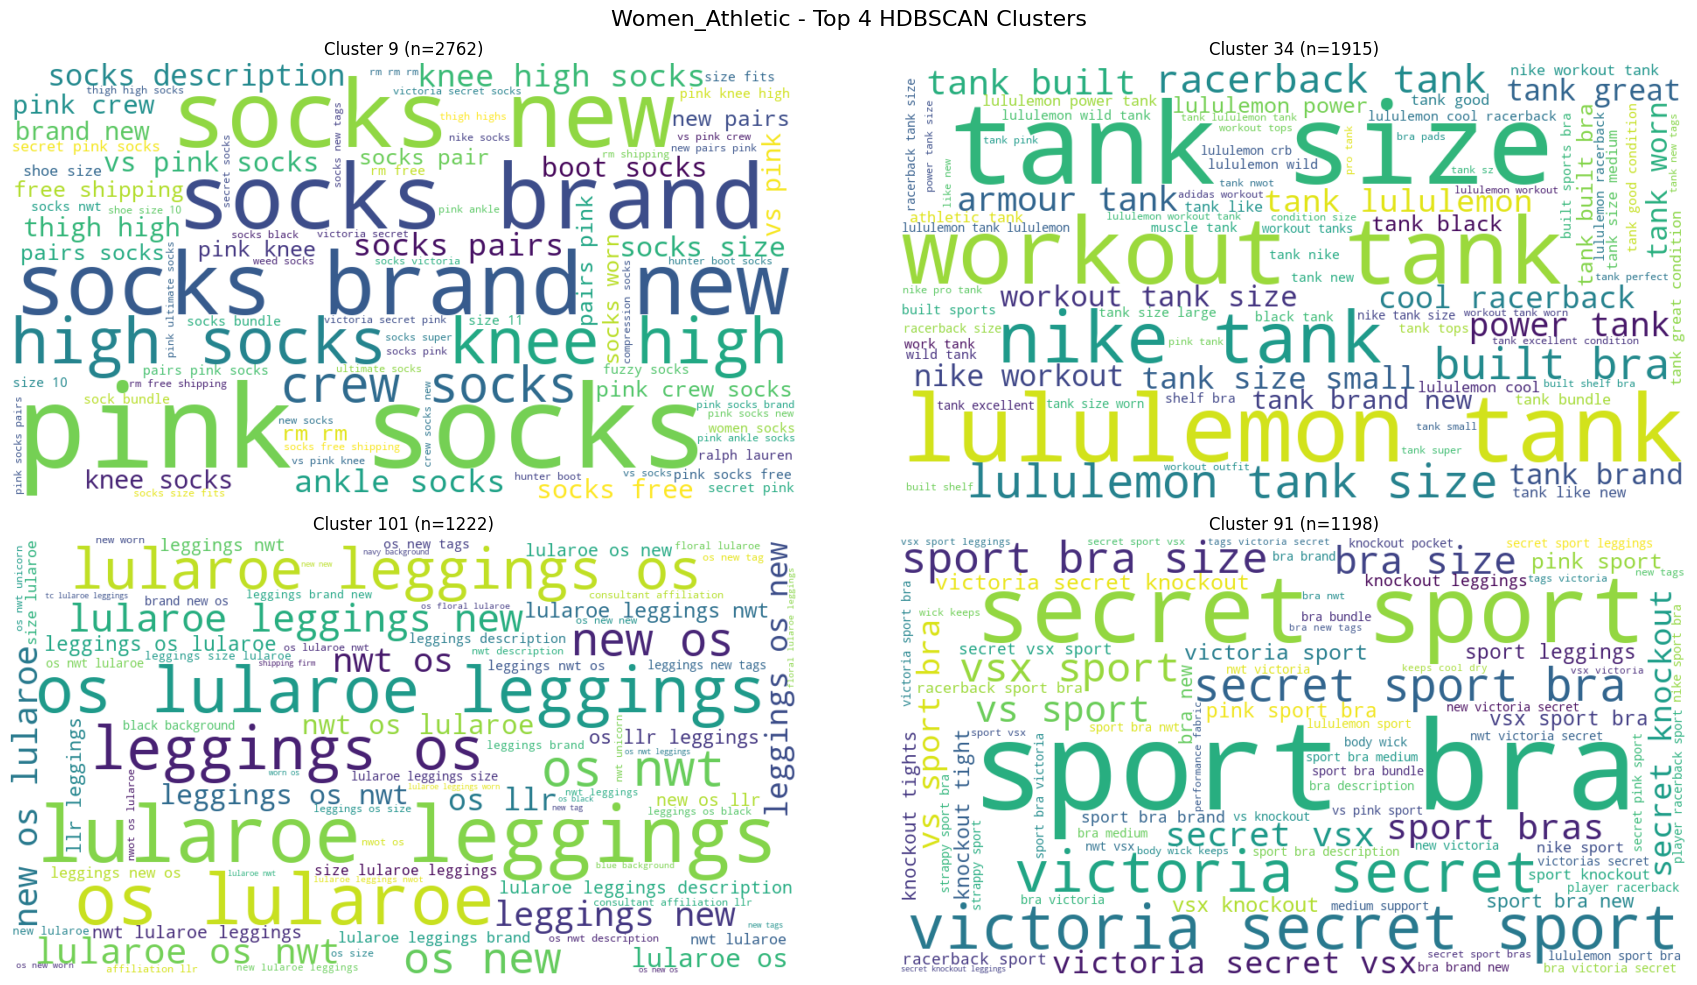

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

'''
brand_map1 = {
    r"\bbrand\s+new": "brandnew",
    r"\bfree\s+ship(ping)?\b" :"freeship",
    r"\bgray\b": "grey",
    r"\bbnwt\b": "nwt",
    r"\bquestions\b":"question",
    r"\bcomfy\b":"comfortable",
    r"\bvictoria(?:'|’)?s?\s+secret\b": "vs",  
    r"\bcalvin\s+klein\b": "ck",
    r"\bmichael\s+kors\b": "mk",
    r"\bamerican\s+eagle\b": "ae",
    r"\bkate\s+spade\b":"ks",
    r"\bkendra\s+scott\b": "kc",
    r"\blouis\s+vuitton\b": "lv",
    r"\bbrandy\s+melville\b":"bm",
    r"\bvera\s+bradley\b":"vd",
    r"\btory\s+burch\b":"tb",
    r"\bnorth\s+face\b":"nf",
    r"\bforever\s+21\b":"f2",
    r"\bcomme\s+des\s+garcons?\b": "cdg",
    r"\bjessica\s+simpson\b":"js",
    }  

def normalize_brands(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    for pattern, replacement in brand_map1.items():
        text = re.sub(pattern, replacement, text)
    return text

train_Women_Athletic['name_description'] = train_Women_Athletic['name_description'].apply(normalize_brands)


no_use_word = ['rm', 'description','size',
    'condition','great','good','excellent','worn','used','new','like','firm','price','shipping','freeship','bundle',
    'tags','tag','brandnew','free','authentic','just', 'times','save','bought','items','box',
    'brand','material','light','long','twice','wear','washed','nwot','nwt','stains','flaws',
    'gently','wore','home','10','don','check','comes','little','100',
    'retail','inside','big','ask','question','dust'
    ]
'''
custom_stopwords = list(ENGLISH_STOP_WORDS.union(no_use_word))

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(2,3),
    min_df=5,
    stop_words='english'         #custom_stopwords
)

X = vectorizer.fit_transform(train_Women_Athletic["name_description"].fillna(""))
feature_names = vectorizer.get_feature_names_out()


import umap

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=10,
    metric="cosine",
    random_state=42
)

X_umap = umap_model.fit_transform(X)

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=200,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom"
)

clusters = clusterer.fit_predict(X_umap)
train_Women_Athletic["cluster"] = clusters

vc = train_Women_Athletic.loc[
    train_Women_Athletic["cluster"] != -1, "cluster"
].value_counts()

top4 = vc.head(4).index.tolist()

print("Top4 clusters:")
print(vc.head(4))

import matplotlib.pyplot as plt
from wordcloud import WordCloud

global_mean = np.asarray(X.mean(axis=0)).ravel()

def build_freqs(cid, top_n=80):
    idx = np.where(clusters == cid)[0]
    X_c = X[idx]

    c_mean = np.asarray(X_c.mean(axis=0)).ravel()

    score = c_mean - global_mean

    top_idx = score.argsort()[-top_n:][::-1]
    freqs = {feature_names[j]: float(score[j])
             for j in top_idx if score[j] > 0}
    if len(freqs) < 10:
        top_idx = c_mean.argsort()[-top_n:][::-1]
        freqs = {feature_names[j]: float(c_mean[j])
                 for j in top_idx if c_mean[j] > 0}

    return freqs
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()

for ax, cid in zip(axes, top4):
    freqs = build_freqs(cid)

    wc = WordCloud(
        width=900,
        height=500,
        background_color="white",
        collocations=False
    ).generate_from_frequencies(freqs)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Cluster {cid} (n={vc[cid]})")

plt.suptitle("Women_Athletic - Top 4 HDBSCAN Clusters", fontsize=16)
plt.tight_layout()
plt.show()